In [168]:
setwd("/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb")
devtools::load_all("utils/modules/R/gwastools")
library(tidyverse)
library(ggforce)
library(data.table)
library(ggplot2)
library(ggrepel)
library(ggsci)
library(ggrastr)
library(latex2exp)

i Loading gwastools



In [169]:
# map from ENSEMBL to HGNC
bridge <- fread("/well/lindgren/flassen/ressources/genesets/genesets/data/biomart/220524_hgnc_ensg_enst_chr_pos.txt.gz")
ensembl_to_hgnc <- bridge$hgnc_symbol
names(ensembl_to_hgnc) <- bridge$ensembl_gene_id
ensembl_to_pos <- (bridge$start_position + bridge$end_position)/2
names(ensembl_to_pos) <- bridge$ensembl_gene_id
ensembl_to_contig <- bridge$chromosome_name
names(ensembl_to_contig) <- bridge$ensembl_gene_id

In [170]:
get_qq_df <- function(files){
    ribbon_p <- 0.95
    d <- do.call(rbind, lapply(files, function(f){
        stopifnot(file.exists(f))
        d <- fread(f)
        if (nrow(d) > 0){
            # read from conditional analysis if present
            if ("p.value_c" %in% colnames(d)) {
                d$p.value <- d$p.value_c
            }
            d$p.value.expt <- get_expected_p(d$p.value, na.rm = TRUE)
            n <- length(d$p.value)
            # create QQ
            dt <- data.table(
                ensembl_gene_id = d$MarkerID[order(d$p.value)],
                pvalue = sort(d$p.value),
                pvalue.observed = -log10(sort(d$p.value)),
                pvalue.expected = -log10(sort(d$p.value.expt)),
                clower = -log10(qbeta(p = (1 - ribbon_p) / 2, shape2 = n:1, shape1 = 1:n)),
                cupper = -log10(qbeta(p = (1 + ribbon_p) / 2, shape2 = n:1, shape1 = 1:n))
            )
            # regex the current phenotype and clean
            dt$prs <- grepl("locoprs", f)
            dt$analysis <- str_extract(basename(f), 'maf0to5e-2_.+_pLoF')
            dt$analysis <- gsub("maf0to5e-2_", "", dt$analysis)
            dt$analysis <- gsub("_pLoF", "", dt$analysis)
            dt$analysis <- gsub("_combined", "", dt$analysis)
                       
            # add hgnc and grch38 position
            dt$hgnc_symbol <- ensembl_to_hgnc[dt$ensembl_gene_id]
            dt$contig <- ensembl_to_contig[dt$ensembl_gene_id]
            dt$pos <- ensembl_to_pos[dt$ensembl_gene_id]
            
            # plot label if deviated from null
            dt$label <- NA 
            bool <- dt$pvalue.observed >= dt$clower & dt$pvalue.observed > 3
            dt$label[bool] <- dt$hgnc_symbol[bool]
            
 
        return(dt)
        } else {
            return(NULL)
        }
    }))
    return(d)
}

In [171]:
pattern <- "pLoF_damaging_missense.txt.gz"
files <- list.files("data/saige/output/binary/step2/min_mac4", pattern = pattern, full.names = TRUE)
files<- files[!grepl("primary_care", files)]
files_no_cond <- files

In [172]:
d <- get_qq_df(files)
length(unique(d$analysis))
sum(d$pvalue == 0)

[1] 37

[1] 0

In [173]:
pattern <- "pLoF_damaging_missense.txt.gz"
files <- list.files("data/saige/output/binary/step2/min_mac4", pattern = pattern, full.names = TRUE)




Warning message:
"Ignoring unknown parameters: label.padding"
Warning message:
"Removed 57210 rows containing missing values (geom_text_repel)."


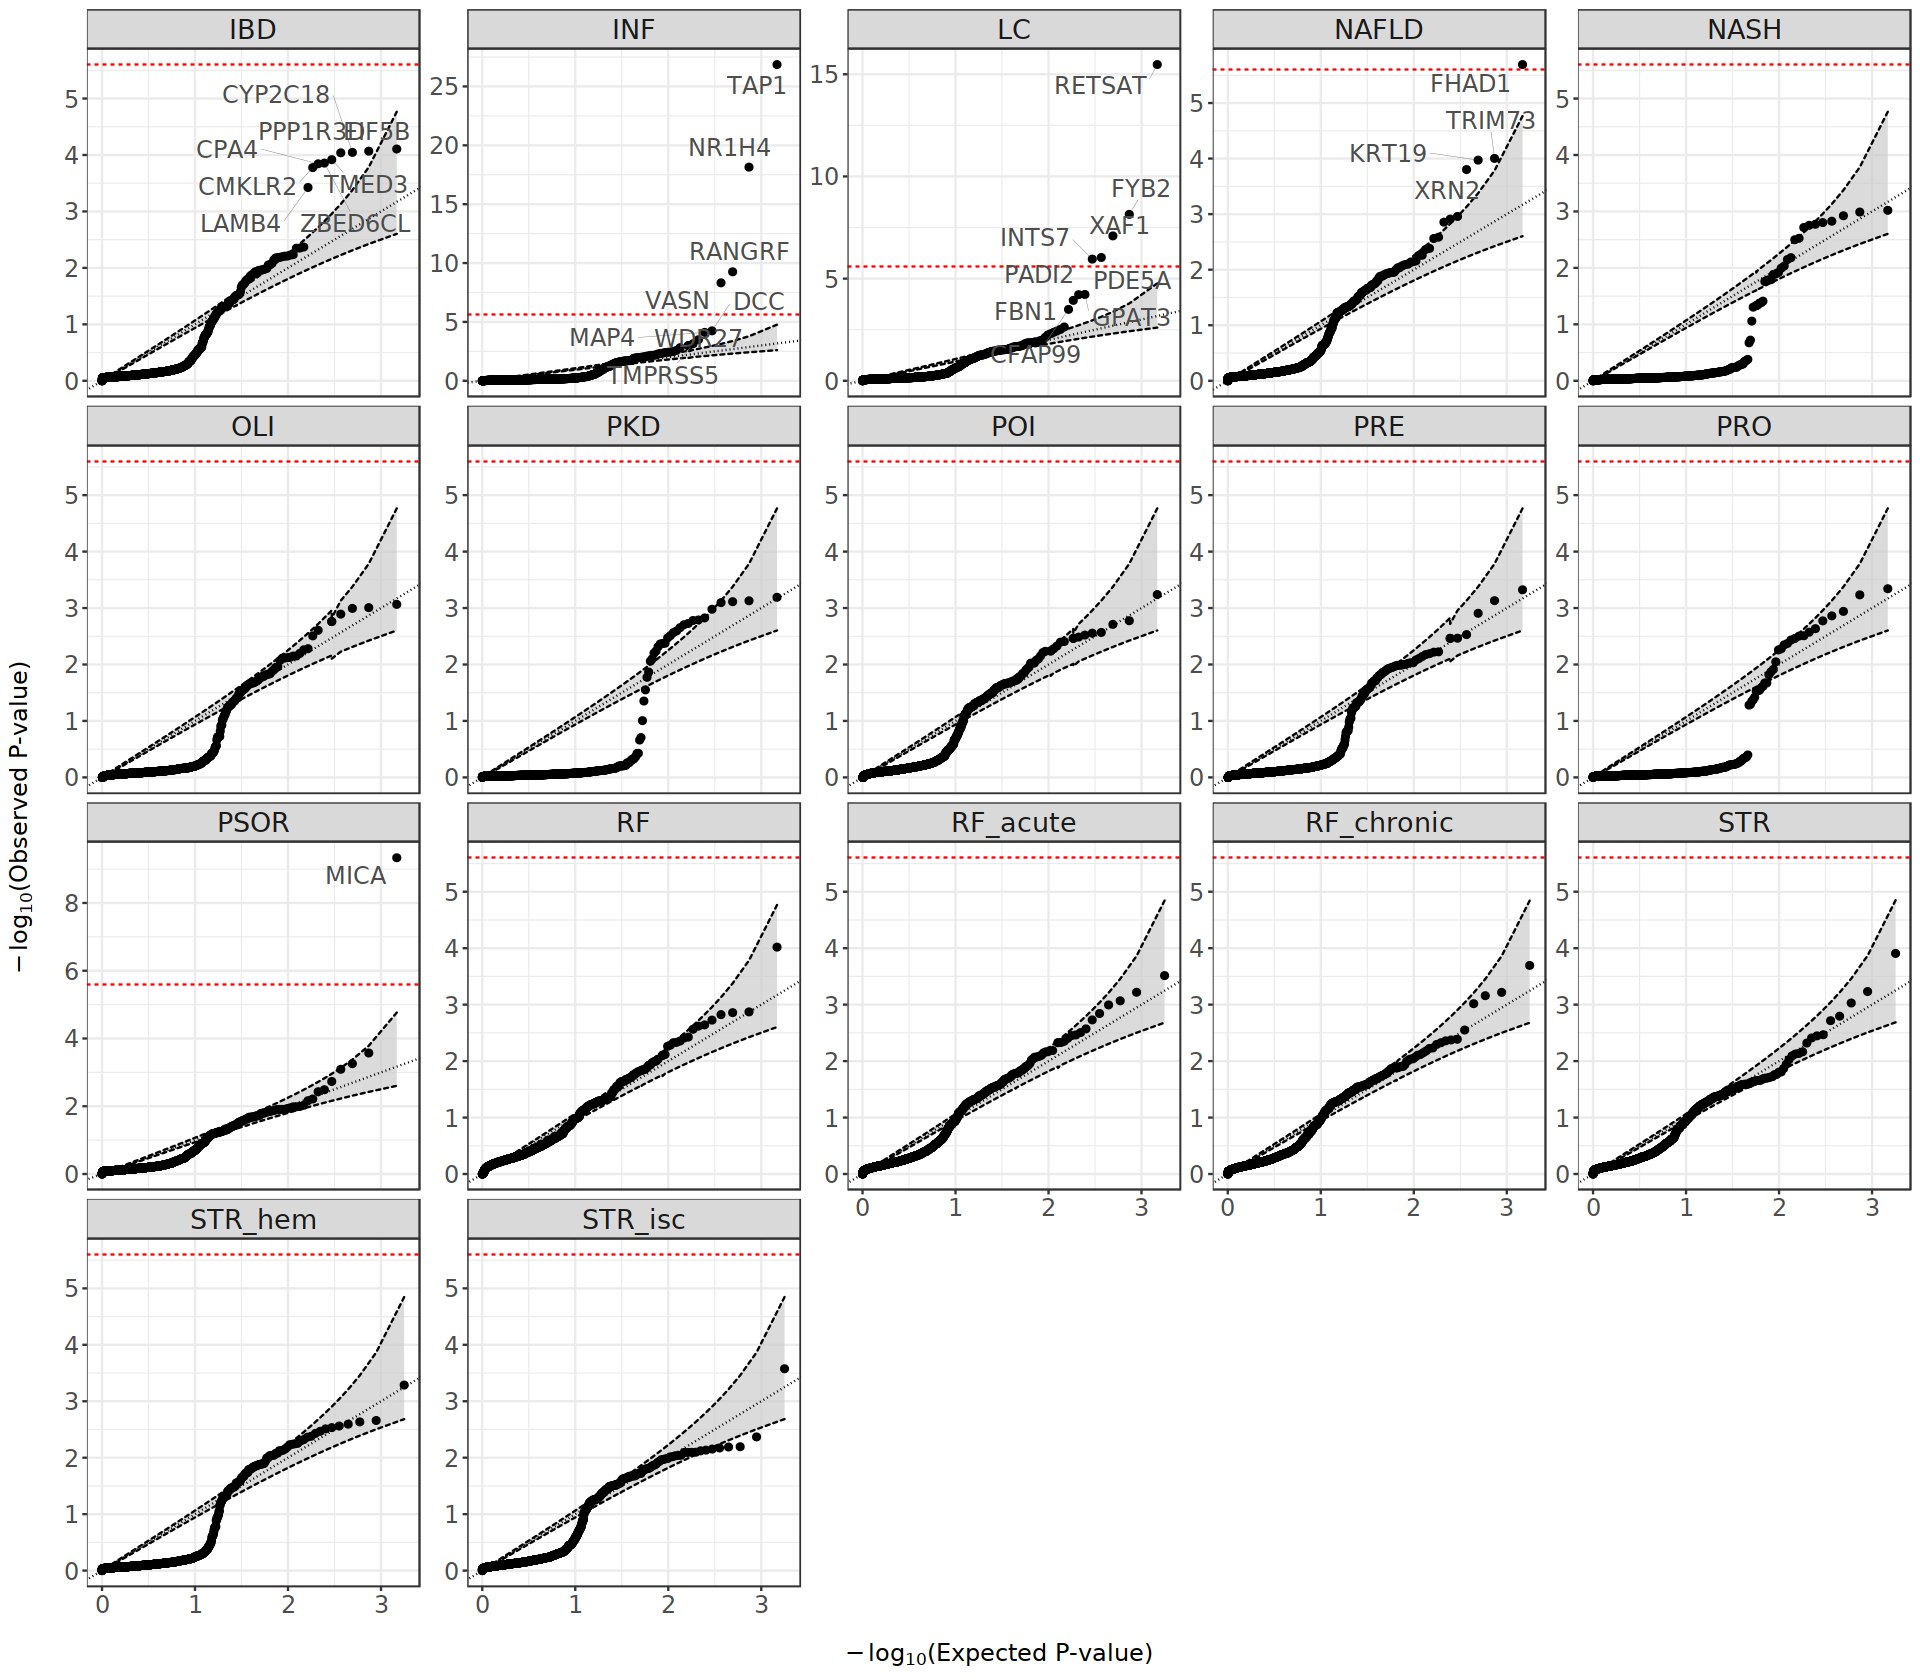

In [174]:
options(repr.plot.width=16, repr.plot.height=14)
bonf <- -log10(0.05 / 20000)
ggplot(d, aes(x=pvalue.expected, y=pvalue.observed, ymax=cupper, ymin=clower, label = label)) +
    geom_ribbon(fill="grey80", color="black", alpha = 0.7, linetype = 'dashed') +
    geom_point() +
    geom_abline(linetype = 'dotted') + 
    geom_hline(yintercept = bonf, color = 'red', linetype = 'dashed') +
    scale_x_continuous(breaks=scales::pretty_breaks(n=5)) +
    scale_y_continuous(breaks=scales::pretty_breaks(n=5)) +
    xlab(expression(paste(-log[10],'(Expected P-value)' ))) +
    ylab(expression(paste(-log[10],'(Observed P-value)' ))) +
    geom_text_repel(
        box.padding = 0.4, label.padding=0.1, point.padding = 0.2,
        color = 'grey30', segment.color = 'grey50', max.overlaps=Inf,
        size=5, segment.size=0.1, show.legend = FALSE
    ) +
    facet_wrap_paginate(~analysis, nrow = 4, ncol = 5, page = 2, scales = "free_y") +
    theme_bw() +
    theme(
        strip.text = element_text(size=16),
        axis.text=element_text(size=14),
        axis.title=element_text(size=14,face="bold"),
        axis.title.x = element_text(margin=ggplot2::margin(t=16)),
        axis.title.y = element_text(margin=ggplot2::margin(r=16)),
        plot.title = element_text(hjust=0.5),
        plot.subtitle = element_text(hjust=0.5),
        legend.position="none"
    )

In [175]:
# helper for getting gene start/end
get_start_and_end <- function(chr_lengths) {
    start <- rep(0, length(chr_lengths))
    start[1] <- 1
    end <- rep(0, length(chr_lengths))
    end[1] <- chr_lengths[1]
    for(chr in 2:length(chr_lengths)) {
        start[chr] <- start[chr-1] + chr_lengths[chr-1]
        end[chr] <- end[chr-1] + chr_lengths[chr]
    }
    return(list(start=start, end=end))
}

# lengths for chromosome
chr_lengths_38 <- c(248956422, 242193529, 198295559,190214555,181538259,170805979,159345973,
    145138636,138394717,133797422,135086622,133275309,114364328,107043718,101991189,90338345,
    83257441,80373285,58617616,64444167,46709983,50818468,156040895)
contigs_ <- c(1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23)

# thresholds for plotting
buffer <- 100000000
significance_T <- 0.05 / (1746 * 37)

In [176]:
# get hits that pass our sig thresholds
sig_table <- as.data.frame(table(d$pvalue < significance_T, d$analysis))
sig_table <- sig_table[sig_table$Var1 == TRUE, ]
sig_table <- sig_table[,c(2,3)]
colnames(sig_table) <- c("phenotype", "hits")

# summarize hits in vector
sig_phenos <- as.character(unique(sig_table$phenotype[sig_table$hits > 0]))
not_sig_phenos <- as.character(unique(sig_table$phenotype[sig_table$hits == 0]))
n_sig <- length(sig_phenos)

In [177]:
# only plot things that are exome wide significnat
dt <- d
#dt$label <- paste0(dt$hgnc_symbol, " (",dt$analysis,")")
dt$label[dt$pvalue > significance_T] <- NA
dt <- dt[dt$analysis %in% sig_phenos,]


nrow(dt)

[1] 14138

In [178]:
dt[(dt$pvalue.observed > -log10(0.05 / (1746 * 37))),]

ensembl_gene_id,pvalue,pvalue.observed,pvalue.expected,clower,cupper,prs,analysis,hgnc_symbol,contig,pos,label
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<chr>,<chr>,<chr>,<dbl>,<chr>
ENSG00000132781,1.50776e-11,10.821668,3.169380,4.765664,2.602734,FALSE,CC,MUTYH,1,45335028,MUTYH
ENSG00000138686,1.54946e-07,6.809820,2.868350,3.784784,2.423776,FALSE,CC,BBS7,4,121847408,BBS7
ENSG00000007306,4.16237e-07,6.380659,2.692259,3.377422,2.311036,FALSE,CC,CEACAM7,19,41690140,CEACAM7
ENSG00000124177,1.87535e-13,12.726918,3.169380,4.765664,2.602734,FALSE,CD,CHD6,20,41510234,CHD6
ENSG00000180801,5.31237e-09,8.274712,2.868350,3.784784,2.423776,FALSE,CD,ARSJ,4,113940006,ARSJ
ENSG00000162654,2.30994e-08,7.636399,2.692259,3.377422,2.311036,FALSE,CD,GBP4,1,89190043,GBP4
ENSG00000104368,4.13191e-08,7.383849,2.567321,3.131432,2.227070,FALSE,CD,PLAT,8,42191214,PLAT
ENSG00000137959,1.70550e-07,6.768148,2.470410,2.958288,2.159638,FALSE,CD,IFI44L,1,78633024,IFI44L
ENSG00000117480,5.31476e-41,40.274516,3.169380,4.765664,2.602734,FALSE,DEM,FAAH,1,46404082,FAAH


In [179]:
#nrow(dt[
#    (dt$pvalue.observed < -log10(0.05 / (1746 * 37))) &
#    (dt$pvalue.observed > -log10(0.05 / 20000))
#    ])

In [180]:
# setup categories
categories <- c(
    "DEM" = "Neurodegenerative",
    "AD" = "Neurodegenerative",
    "CC" = "Cancer",
    "LC" = "Cancer",
    "INF" = "Infertility",
    "DM_GD" = "Metabolic",
    "DM_T1D" = "Metabolic",
    "DM_T2D" = "Metabolic",
    "NAFLD" = "Metabolic",
    "PSOR" = "Psoriasis",
    "CD" = "Crohns disease"
)

# add to data.frame
all_categories <- unique(categories)
n_categories <- length(all_categories)
dt$categories <- categories[dt$analysis]

In [181]:
# color coding
dt$colors <- dt$categories
dt$colors[dt$pvalue > significance_T ] <- ""

In [182]:
# setup color scale
my_colors <- c(rev(RColorBrewer::brewer.pal(n_categories, "Dark2")), "grey")
names(my_colors) <- c(all_categories, "")

fill_scale <- scale_fill_manual(name = "Group", values = my_colors)
color_scale <- scale_color_manual(name = "Group", values = my_colors)

In [183]:
contigs <- dt$contig
positions <- dt$pos
pvals <- dt$pvalue.observed
labels <- dt$label
phenotypes <- dt$analysis
colors <- dt$colors
c(contigs[1],positions[1],pvals[1],labels[1],phenotypes[1],colors[1])

[1] "1"                "45335028"         "10.8216677824522" "MUTYH"           
[5] "CC"               "Cancer"

In [184]:
# get contigs
start_end <- get_start_and_end(chr_lengths_38)
dt_contigs <- data.frame(contig=contigs_, start=start_end$start, end=start_end$end) %>%
mutate(middle = floor(start + (end-start)/2),
       length = (end-start)) %>%
mutate(shifted_position=middle + (contig - 1) * buffer)

In [185]:
# setup plotting
dt_plot <- data.frame(
    contig=contigs, 
    position=as.integer(positions), 
    pval=as.numeric(pvals), 
    labels=labels,
    phenotype=phenotypes,
    colors = colors
) %>% mutate(
        x = dt_contigs[gsub('X', '23', contig), 'start'] + position + (as.integer(gsub('X', '23', contig))-1)*buffer,
        y = pvals
)



In [186]:
#dt_plot <- dt_plot[dt_plot]

Warning message:
"Removed 24 rows containing missing values (geom_point)."
Warning message:
"Removed 14106 rows containing missing values (geom_label_repel)."


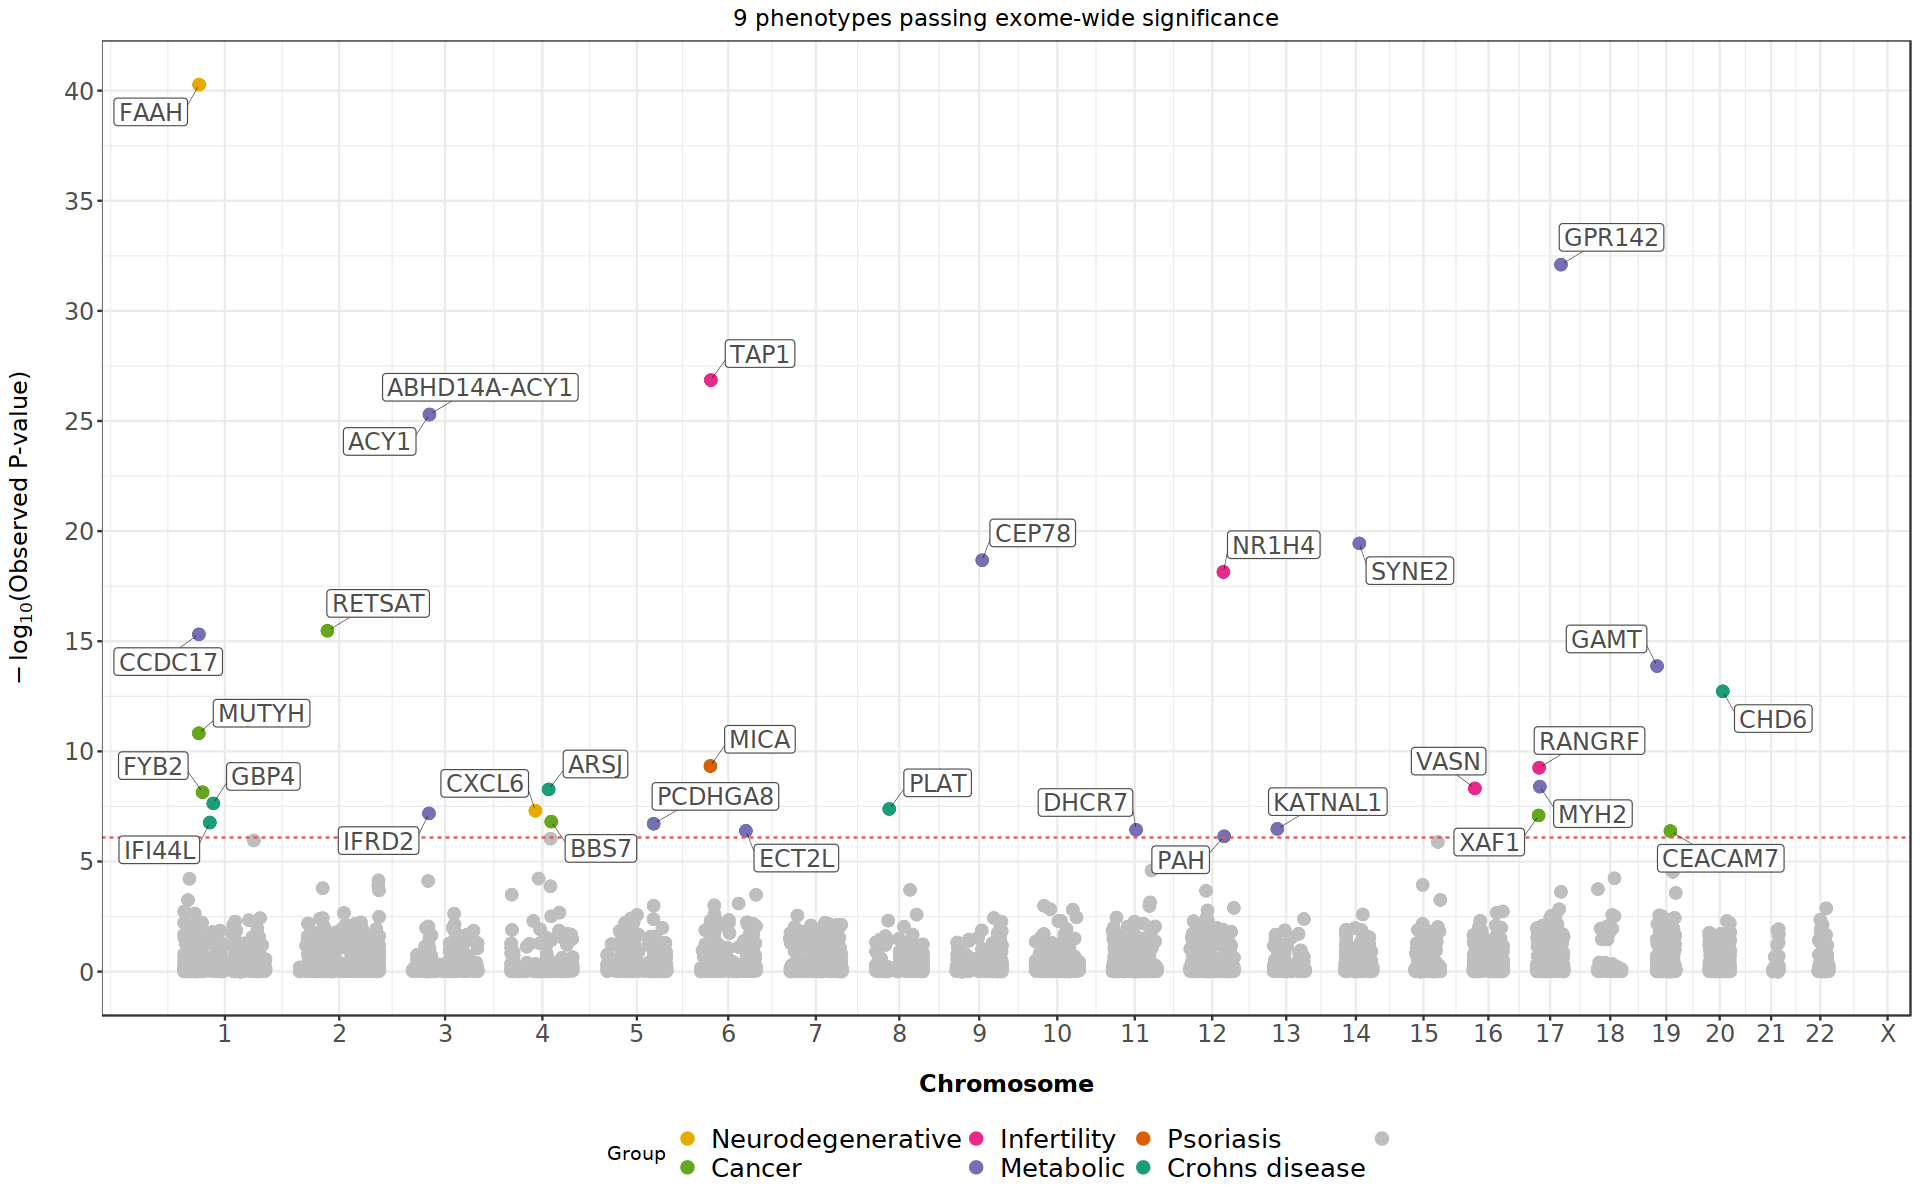

In [187]:
options(repr.plot.width=16, repr.plot.height=10)
p <- ggplot(dt_plot, aes(x=x,y=y,label=labels, color=colors)) + 
    geom_point_rast(size=3) +
    color_scale +
    geom_hline(yintercept=-log10(significance_bonf_T), color='#E15759', linetype='dashed') +
    scale_x_continuous(breaks=dt_contigs$shifted_position, labels=gsub(23, 'X', dt_contigs$contig)) +
    scale_y_continuous(breaks=scales::pretty_breaks(n=10)) +
    geom_label_repel(
        box.padding = 0.5, label.padding=0.2, point.padding = 0.2,
        color = 'grey30', segment.color = 'black', max.overlaps=Inf,
        size=5, segment.size=0.1, show.legend = FALSE
    ) +
    xlab("Chromosome") +
    ylab(expression(paste(-log[10],'(Observed P-value)' ))) +
    theme_bw() +
    theme(
        axis.text=element_text(size=14),
        axis.title=element_text(size=14,face="bold"),
        axis.title.x = element_text(margin=ggplot2::margin(t=16)),
        axis.title.y = element_text(margin=ggplot2::margin(r=16)),
        plot.title = element_text(hjust=0.5),
        plot.subtitle = element_text(hjust=0.5),
        legend.position="bottom",
        legend.text=element_text(size=15)
    ) +
    ggtitle(paste0(n_sig," phenotypes passing exome-wide significance"))

p

In [198]:
#ggsave("test.pdf", width = 14, height = 10)

In [197]:
#dt[
#    (dt$pvalue.observed =< -log10(significance_bonf_T)) &
#    (dt$pvalue.observed > -log10(0.05 / 20000))
#    ,]